In [17]:
import json
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
import vector
import pandas as pd

In [2]:
def to_p4(p4_obj):
    return vector.awk(
        ak.zip(
            {
                "mass": p4_obj.tau,
                "x": p4_obj.x,
                "y": p4_obj.y,
                "z": p4_obj.z,
            }
        )
    )

In [3]:
output_dir = '/home/norman/ml-tau/ml-tau-en-reg/training-outputs/260210_charge_classification_e50/charge_classification/ParticleTransformer'
history_path = f'{output_dir}/history.json'
test_results_path = f'{output_dir}/zz_test.parquet'

In [4]:
with open(history_path, 'r') as f:
    history = json.load(f)

In [5]:
test_data = ak.from_parquet(test_results_path)
preds = test_data['charge_classification']['pred']
targets = test_data['charge_classification']['target']

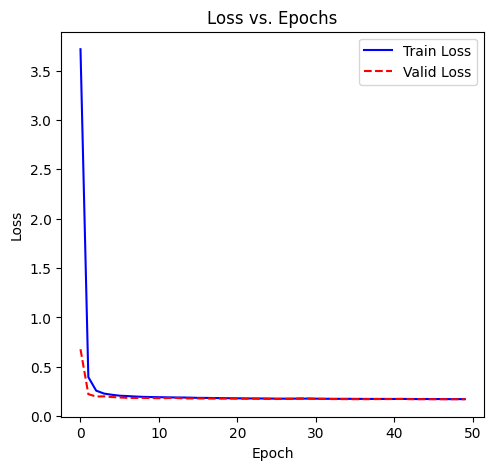

In [6]:
plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history['loss_train'], label='Train Loss', color='blue')
plt.plot(history['loss_validation'], label='Valid Loss', color='red', linestyle='--')
plt.title('Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

Saved learning_curves.png


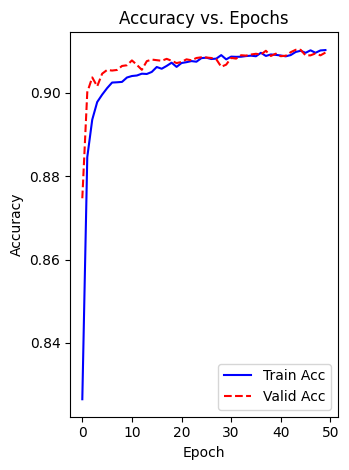

In [7]:
# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(history['accuracy_train'], label='Train Acc', color='blue')
plt.plot(history['accuracy_validation'], label='Valid Acc', color='red', linestyle='--')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('learning_curves.png')
print("Saved learning_curves.png")

In [8]:
# Confusion Matrix
preds_np = ak.to_numpy(preds)
targets_np = ak.to_numpy(targets)
y_pred = (preds_np > 0.5).astype(int)
cm = confusion_matrix(targets_np, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

Text(0.5, 1.0, 'Charge Classification: Normalized Confusion Matrix')

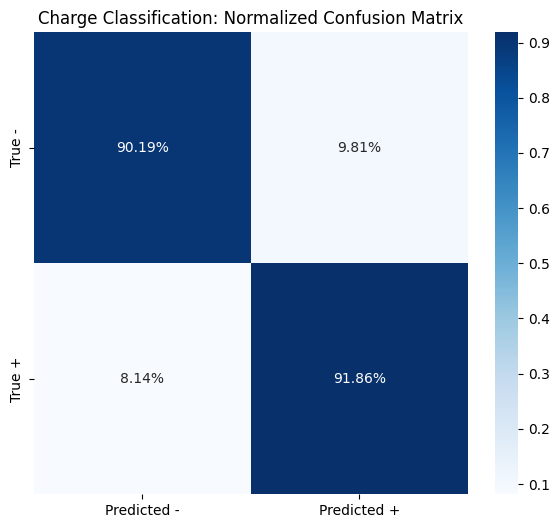

In [9]:
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Predicted -', 'Predicted +'], 
            yticklabels=['True -', 'True +'])
plt.title('Charge Classification: Normalized Confusion Matrix')

In [3]:
zz_test = ak.from_parquet("/scratch/persistent/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/260206/zz_test.parquet")

In [11]:
mask = to_p4(zz_test.reco_jet_p4s).pt > 5
data_ptcut = zz_test[mask]

In [12]:
pf_pid = data_ptcut.reco_cand_pdg
gen_charge = data_ptcut.gen_jet_tau_charge
pf_charges = data_ptcut.reco_cand_charge
jet_charge_sum = ak.sum(pf_charges, axis=1)
baseline_score = ak.to_numpy(jet_charge_sum)
model_score = test_data.charge_classification.pred
target = test_data.charge_classification.target

In [13]:
# particletransformer
fpr_model, tpr_model, _ = roc_curve(target, model_score)
auc_model = auc(fpr_model, tpr_model)

# baseline
fpr_base, tpr_base, _ = roc_curve(target, baseline_score)
auc_base = auc(fpr_base, tpr_base)

In [21]:
baseline_score

array([-1.,  1.,  1., ...,  1.,  0., -1.], shape=(42276,))

In [14]:
auc_base, auc_model

(0.9506330337854896, 0.9805035840687234)

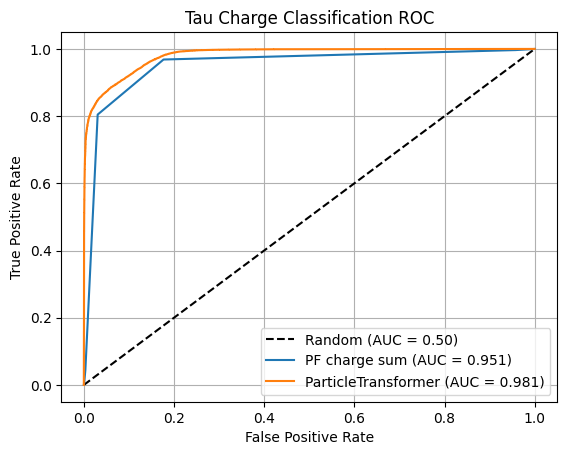

In [15]:
plt.figure()

# diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

# baseline
plt.plot(fpr_base, tpr_base, 
         label=f'PF charge sum (AUC = {auc_base:.3f})')

# particletransformer
plt.plot(fpr_model, tpr_model, 
         label=f'ParticleTransformer (AUC = {auc_model:.3f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Tau Charge Classification ROC')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
np.unique(baseline_score)

array([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.])

In [17]:
fpr_base, tpr_base, thresholds = roc_curve(targets, baseline_score)
J = tpr_base - fpr_base
ix = np.argmax(J)
best_threshold = thresholds[ix]

print("Best threshold for base:", best_threshold)

Best threshold for base: 0.0


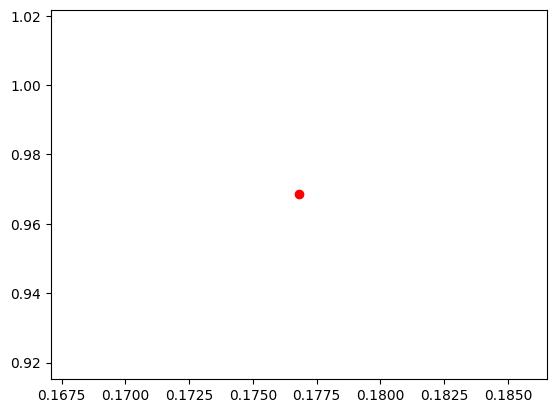

In [18]:
plt.plot(fpr_base[ix], tpr_base[ix], 'ro')

In [19]:
fpr_base

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       7.21015189e-04, 3.46087291e-03, 3.07152471e-02, 1.76792924e-01,
       9.57363968e-01, 9.96154586e-01, 9.99375120e-01, 9.99951932e-01,
       1.00000000e+00])

In [20]:
tpr_base

array([0.00000000e+00, 4.65722802e-05, 2.32861401e-04, 6.52011923e-04,
       4.51751118e-03, 4.48956781e-02, 8.04629285e-01, 9.68470566e-01,
       9.96553651e-01, 9.99627422e-01, 9.99906855e-01, 1.00000000e+00,
       1.00000000e+00])

In [11]:
to_p4(zz_test.reco_jet_p4s).energy

<Array [23.3, 59.1, 116, 93.7, ..., 31.5, 26.1, 91.6] type='45142 * float64'>

In [15]:
to_p4(zz_test.reco_jet_p4s).mass

<Array [0.584, 1.32, 8.61, 12.5, ..., 0.798, 3.21, 1.86] type='45142 * float64'>

In [22]:
df = pd.DataFrame({
    "gen tau mass": to_p4(zz_test.gen_jet_tau_p4s).mass,
    "reco jet mass": to_p4(zz_test.reco_jet_p4s).mass,
    "reco jet energy": to_p4(zz_test.reco_jet_p4s).energy,
})
df.head(20)

,gen tau mass,reco jet mass,reco jet energy
0,0.686135,0.584124,23.348945
1,1.268716,1.323452,59.106787
2,0.139570,8.605453,116.037641
3,1.200511,12.492187,93.651179
4,1.310832,7.139637,42.669783
5,0.831817,0.595248,11.706705
6,0.837990,13.432933,130.993192
7,0.959967,0.938840,15.790673
8,0.139570,1.137127,57.638866
9,0.830873,0.873401,12.285801


In [23]:
import enreg.tools.general as g

In [24]:
gen_jet_tau_p4s = g.reinitialize_p4(zz_test.gen_jet_tau_p4s)

In [ ]:
mass_target = gen_tau_mass / (reco_jet_energy + eps)

In [29]:
gen_jet_tau_p4s.mass

<Array [0.686, 1.27, 0.14, 1.2, ..., 1.21, 0.933, 1.01] type='45142 * float64'>